<a href="https://colab.research.google.com/github/SubhashreeVP22/aiml-assignment/blob/main/logistic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving tata_preprocessed.csv to tata_preprocessed.csv
Accuracy: 0.7813765182186235


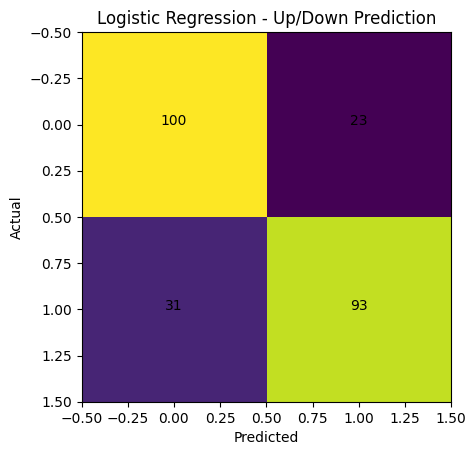

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from google.colab import files
uploaded = files.upload()
# Load
df = pd.read_csv("tata_preprocessed.csv")

# Create classification target
df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)

# Drop last row (NaN after shift)
df = df.dropna()

# Features
X = df[['Open', 'High', 'Low']]
y = df['Target']

# Split (time series → no shuffle)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Model
model = LogisticRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.imshow(cm)
plt.title("Logistic Regression - Up/Down Prediction")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i][j], ha='center')

plt.show()